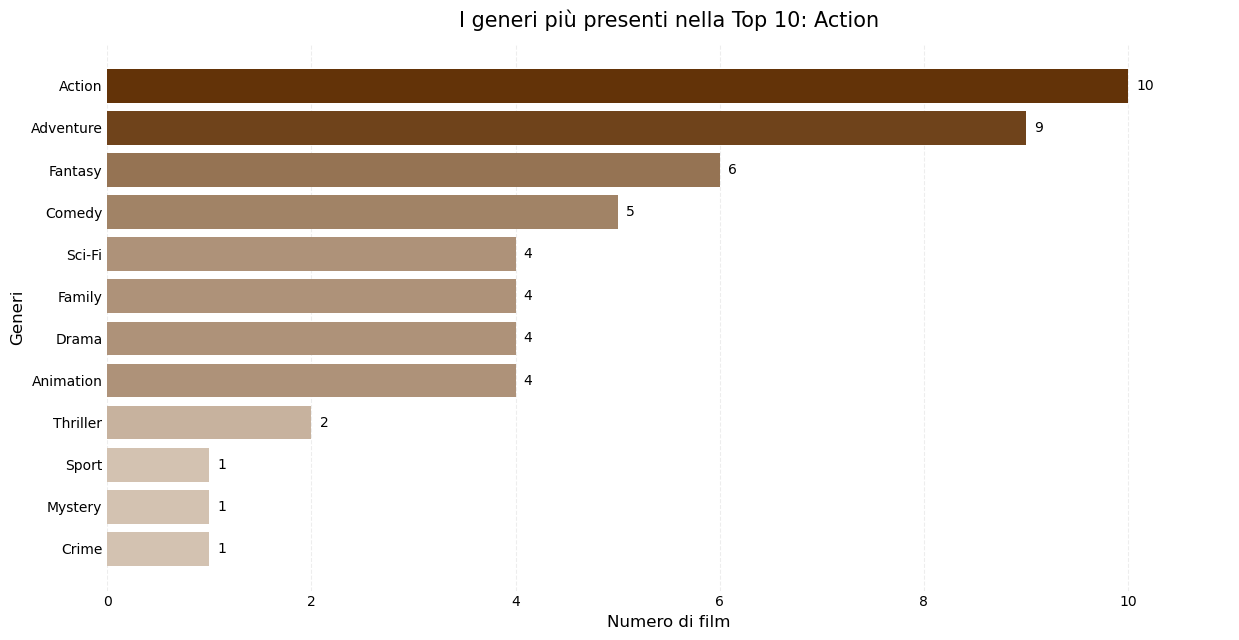

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from matplotlib.colors import to_rgb

def leggi_csv():
    nomi = ["Generefilm.csv", "Genere film - Foglio1.csv", "Genere film .csv"]
    for n in nomi:
        try:
            df = pd.read_csv(n)
            df.columns = df.columns.str.strip()
            return df
        except:
            pass
    raise FileNotFoundError("Non trovo il file dei generi (Generefilm.csv / Genere film - Foglio1.csv)")

df = leggi_csv()

col_film = None
for c in df.columns:
    if c.lower() in ["nome film", "nome del film", "movie", "film", "titolo", "title"]:
        col_film = c
        break

df2 = df.copy()
if col_film is not None:
    df2 = df2.set_index(col_film)

is_matrix = False
if df2.shape[1] >= 2:
    vals = df2.iloc[:, :].copy()
    for c in vals.columns:
        vals[c] = pd.to_numeric(vals[c], errors="coerce")
    if vals.notna().sum().sum() > 0:
        vset = set(np.unique(vals.dropna().to_numpy()))
        if vset.issubset({0, 1}):
            is_matrix = True

if is_matrix:
    df_filled = df2.fillna(0)
    for c in df_filled.columns:
        df_filled[c] = pd.to_numeric(df_filled[c], errors="coerce").fillna(0).astype(int)
    conteggi = df_filled.sum(axis=0)
else:
    col_genere = None
    for c in df.columns:
        if "genere" in c.lower() or "genre" in c.lower():
            col_genere = c
            break
    if col_genere is None:
        raise ValueError("Non trovo una colonna 'Genere/Genre' e il file non sembra una matrice 0/1.")
    s = df[col_genere].astype(str)
    sep_pattern = r"[,\|;/]| & | and |/|•"
    generi = []
    for x in s:
        x = x.strip()
        if x.lower() in ["nan", "none", "-", ""]:
            continue
        parts = re.split(sep_pattern, x, flags=re.IGNORECASE)
        parts = [p.strip() for p in parts if p.strip() != ""]
        generi.extend(parts)
    conteggi = pd.Series(generi).value_counts()

conteggi = conteggi.sort_values(ascending=True)
generi = conteggi.index.tolist()
valori = conteggi.values.astype(int)

base_hex = "#633308"
base_rgb = np.array(to_rgb(base_hex))
light_rgb = np.array(to_rgb("#efe6db"))

vmin, vmax = valori.min(), valori.max()
if vmax == vmin:
    t = np.ones_like(valori, dtype=float)
else:
    t = (valori - vmin) / (vmax - vmin)
t = 0.20 + 0.80 * t
colori = [tuple(light_rgb * (1 - ti) + base_rgb * ti) for ti in t]

fig, ax = plt.subplots(figsize=(12.5, 6.5))

bars = ax.barh(generi, valori, color=colori, edgecolor="none")

ax.set_xlabel("Numero di film", fontsize=12)
ax.set_ylabel("Generi", fontsize=12)

top1 = conteggi.sort_values(ascending=False).index[0]
ax.set_title(f"I generi più presenti nella Top 10: {top1}", fontsize=15, pad=12)

ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.22)
ax.yaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)

xmax = max(valori) if len(valori) else 0
for b, v in zip(bars, valori):
    ax.text(v + 0.08, b.get_y() + b.get_height()/2, f"{int(v)}", va="center", ha="left", fontsize=10)

ax.set_xlim(0, xmax + 1)

plt.tight_layout()
plt.show()